# Human Action Detection

---

# Step1: Importing Libraries

Downloading the data csv file from the kaggle website.

In [2]:

import kagglehub
path=kagglehub.dataset_download("gaurav2022/mobile-health")
print(path)

C:\Users\aarti\.cache\kagglehub\datasets\gaurav2022\mobile-health\versions\1


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


---

## Essential tools- 
These are essential tools from the scikit learn (sklearn) library, which is the standard for machine learning in Python. They are primarily used for preparing your data and optimizing your models.

Here is a breakdown of what each one does:

### *1. Data Resampling & Balancing*
resample: Used primarily to balance datasets. If your dataset has a class imbalance (e.g., 90% "No" and 10% "Yes"), you can use this to upsample the minority class or downsample the majority class so the model learns from both effectively.

### *2. Data Transformation (Preprocessing)*
LabelEncoder: Converts categorical text data (like "Cat", "Dog", "Bird") into numerical labels (0, 1, 2). Machine learning models cannot process raw text, so this is a standard first step for target variables.

- ### RobustScaler: 
Scales data based on percentiles (median and interquartile range). It is "robust" because it is not heavily influenced by outliers. If your data has extreme values that would skew a standard average, use this.

- ### StandardScaler: 
Standardizes features by removing the mean and scaling to unit variance (making the mean 0 and standard deviation 1). This is the most common scaler and is essential for algorithms that rely on distance calculations, like K-Nearest Neighbors or SVMs.

### *3. Model Workflow*
train_test_split: Splits the dataset into two subsets: one for training the model (usually 70-80%) and one for testing its performance (20-30%). This is crucial to ensure your model can perform well on data it hasn't seen before.

- ### GridSearchCV:
Automates the process of "Hyperparameter Tuning." Instead of manually testing different settings for your model, you provide a grid of possible parameters, and it exhaustively tries every combination using cross-validation to find the one that yields the best performance.

In [4]:
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder 
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV


---


## Importing important ML Models
Theory regarding each model is in the [README](README.md) file


In [5]:

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import statsmodels.api as sm
from sklearn.metrics import classification_report, accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error


## *classification_report*
- What it does: It creates a table summarizing how well your classifier performs for each individual class (e.g., Class 0 vs. Class 1).
- Accuracy is often misleading (e.g., if 99% of your data is "No," a model that just says "No" every time is 99% accurate but useless).
This report provides:
    - Precision: Of all predicted "Yes," how many were actually "Yes"?
    - Recall: Of all actual "Yes" cases, how many did we find?
    - F1-Score: The "harmonic mean" that balances precision and recall.

## *r2_score* 
- What it does: It measures how well the regression model fits the data.
- The Theory: It compares the model's predictions to a "baseline" (a model that just predicts the average of the data).
    - $R^2 = 1$: Perfect prediction.
    - $R^2 = 0$: Your model is no better than just predicting the mean.
    - $R^2 < 0$: Your model is actually worse than just guessing the mean.

In [6]:
from sklearn.metrics import classification_report, r2_score

# Step2: Data Importing & Analysis

In [7]:
df=pd.read_csv("data.csv")
df

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
0,2.1849,-9.6967,0.63077,0.103900,-0.84053,-0.68762,-8.6499,-4.5781,0.187760,-0.449020,-1.01030,0.034483,0,subject1
1,2.3876,-9.5080,0.68389,0.085343,-0.83865,-0.68369,-8.6275,-4.3198,0.023595,-0.449020,-1.01030,0.034483,0,subject1
2,2.4086,-9.5674,0.68113,0.085343,-0.83865,-0.68369,-8.5055,-4.2772,0.275720,-0.449020,-1.01030,0.034483,0,subject1
3,2.1814,-9.4301,0.55031,0.085343,-0.83865,-0.68369,-8.6279,-4.3163,0.367520,-0.456860,-1.00820,0.025862,0,subject1
4,2.4173,-9.3889,0.71098,0.085343,-0.83865,-0.68369,-8.7008,-4.1459,0.407290,-0.456860,-1.00820,0.025862,0,subject1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1215740,1.7849,-9.8287,0.29725,-0.341370,-0.90056,-0.61493,-3.7198,-8.9071,0.294230,0.041176,-0.99384,-0.480600,0,subject10
1215741,1.8687,-9.8766,0.46236,-0.341370,-0.90056,-0.61493,-3.7160,-8.7455,0.448140,0.041176,-0.99384,-0.480600,0,subject10
1215742,1.6928,-9.9290,0.16631,-0.341370,-0.90056,-0.61493,-3.8824,-9.1155,0.450480,0.041176,-0.99384,-0.480600,0,subject10
1215743,1.5279,-9.6306,0.30458,-0.341370,-0.90056,-0.61493,-3.5564,-9.1441,0.594880,0.041176,-0.99384,-0.480600,0,subject10


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1215745 entries, 0 to 1215744
Data columns (total 14 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   alx       1215745 non-null  float64
 1   aly       1215745 non-null  float64
 2   alz       1215745 non-null  float64
 3   glx       1215745 non-null  float64
 4   gly       1215745 non-null  float64
 5   glz       1215745 non-null  float64
 6   arx       1215745 non-null  float64
 7   ary       1215745 non-null  float64
 8   arz       1215745 non-null  float64
 9   grx       1215745 non-null  float64
 10  gry       1215745 non-null  float64
 11  grz       1215745 non-null  float64
 12  Activity  1215745 non-null  int64  
 13  subject   1215745 non-null  object 
dtypes: float64(12), int64(1), object(1)
memory usage: 129.9+ MB


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
alx,1215745.0,1.494200,3.826485,-22.1460,0.14131,1.308900,2.575800,20.0540
aly,1215745.0,-9.692878,4.171303,-19.6190,-10.20100,-9.670300,-9.042200,21.1610
alz,1215745.0,-0.954806,5.461803,-19.3730,-2.64940,-0.016456,1.301300,25.0150
glx,1215745.0,-0.001599,0.491217,-2.1466,-0.43599,-0.014842,0.448980,60.4840
gly,1215745.0,-0.616632,0.354641,-7.7899,-0.81801,-0.707320,-0.540340,2.0113
glz,1215745.0,-0.158781,0.546798,-2.6267,-0.59332,-0.190570,0.322200,2.7701
arx,1215745.0,-3.713413,4.763586,-22.3610,-6.07600,-2.977600,-1.193700,19.8640
ary,1215745.0,-5.805526,5.757639,-18.9720,-9.40420,-7.461500,-2.533900,22.1910
arz,1215745.0,2.393880,3.876503,-18.2390,0.12965,1.928100,4.914700,25.7410
grx,1215745.0,-0.276106,0.527689,-8.3392,-0.70588,-0.354900,0.096078,3.3196


In [10]:
df.isnull().sum()

alx         0
aly         0
alz         0
glx         0
gly         0
glz         0
arx         0
ary         0
arz         0
grx         0
gry         0
grz         0
Activity    0
subject     0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='Activity'>

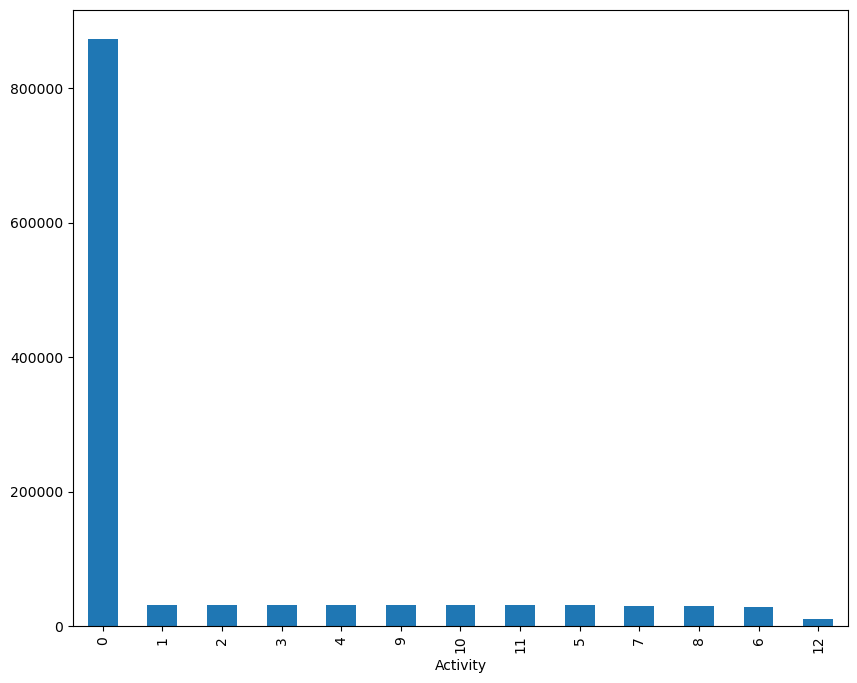

In [12]:
plt.figure(figsize=(10,8))
df["Activity"].value_counts().plot.bar()

As ACtivity has lot of rows with 0 entry we 

In [13]:
data_activity_0=df[df["Activity"]==0]
data_activity_else=df[df["Activity"]!=0]


In [14]:
data_activity_0

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
0,2.1849,-9.6967,0.63077,0.103900,-0.84053,-0.68762,-8.6499,-4.5781,0.187760,-0.449020,-1.01030,0.034483,0,subject1
1,2.3876,-9.5080,0.68389,0.085343,-0.83865,-0.68369,-8.6275,-4.3198,0.023595,-0.449020,-1.01030,0.034483,0,subject1
2,2.4086,-9.5674,0.68113,0.085343,-0.83865,-0.68369,-8.5055,-4.2772,0.275720,-0.449020,-1.01030,0.034483,0,subject1
3,2.1814,-9.4301,0.55031,0.085343,-0.83865,-0.68369,-8.6279,-4.3163,0.367520,-0.456860,-1.00820,0.025862,0,subject1
4,2.4173,-9.3889,0.71098,0.085343,-0.83865,-0.68369,-8.7008,-4.1459,0.407290,-0.456860,-1.00820,0.025862,0,subject1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1215740,1.7849,-9.8287,0.29725,-0.341370,-0.90056,-0.61493,-3.7198,-8.9071,0.294230,0.041176,-0.99384,-0.480600,0,subject10
1215741,1.8687,-9.8766,0.46236,-0.341370,-0.90056,-0.61493,-3.7160,-8.7455,0.448140,0.041176,-0.99384,-0.480600,0,subject10
1215742,1.6928,-9.9290,0.16631,-0.341370,-0.90056,-0.61493,-3.8824,-9.1155,0.450480,0.041176,-0.99384,-0.480600,0,subject10
1215743,1.5279,-9.6306,0.30458,-0.341370,-0.90056,-0.61493,-3.5564,-9.1441,0.594880,0.041176,-0.99384,-0.480600,0,subject10


In [15]:
data_activity_else

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
6656,2.6493,-9.4517,0.37683,-0.20965,-0.88931,-0.50884,-2.8439,-9.0618,1.81770,-0.058824,-0.93429,-0.344830,1,subject1
6657,2.4157,-9.5306,0.40179,-0.20965,-0.88931,-0.50884,-2.9935,-9.2048,1.51890,-0.058824,-0.93429,-0.344830,1,subject1
6658,2.3865,-9.5991,0.48141,-0.20037,-0.86867,-0.50688,-2.8846,-9.1945,1.55070,-0.058824,-0.93429,-0.344830,1,subject1
6659,2.3758,-9.5997,0.42919,-0.20037,-0.86867,-0.50688,-2.9245,-9.1746,1.54130,-0.078431,-0.93429,-0.340520,1,subject1
6660,2.3239,-9.5406,0.40038,-0.20037,-0.86867,-0.50688,-2.8963,-9.2039,1.61270,-0.078431,-0.93429,-0.340520,1,subject1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1213641,-2.4873,-19.2330,3.46140,0.61967,-0.33771,-0.82711,-8.2348,-4.9652,2.48090,-0.437250,-1.01850,0.079741,12,subject10
1213642,-21.5910,-19.4370,-6.04190,0.61967,-0.33771,-0.82711,-21.3180,-10.2130,3.65600,-0.437250,-1.01850,0.079741,12,subject10
1213643,7.5433,-19.2450,-2.66800,0.61967,-0.33771,-0.82711,-21.2970,-18.7050,4.46060,-0.437250,-1.01850,0.079741,12,subject10
1213644,3.0142,-19.3340,-7.70740,0.71058,-0.27017,-0.75442,-21.1380,-18.6980,1.15880,-0.425490,-1.03700,0.084052,12,subject10


In [16]:
data_activity_0= data_activity_0.sample(n=40000)
df=pd.concat([data_activity_0,data_activity_else])

<Axes: xlabel='Activity'>

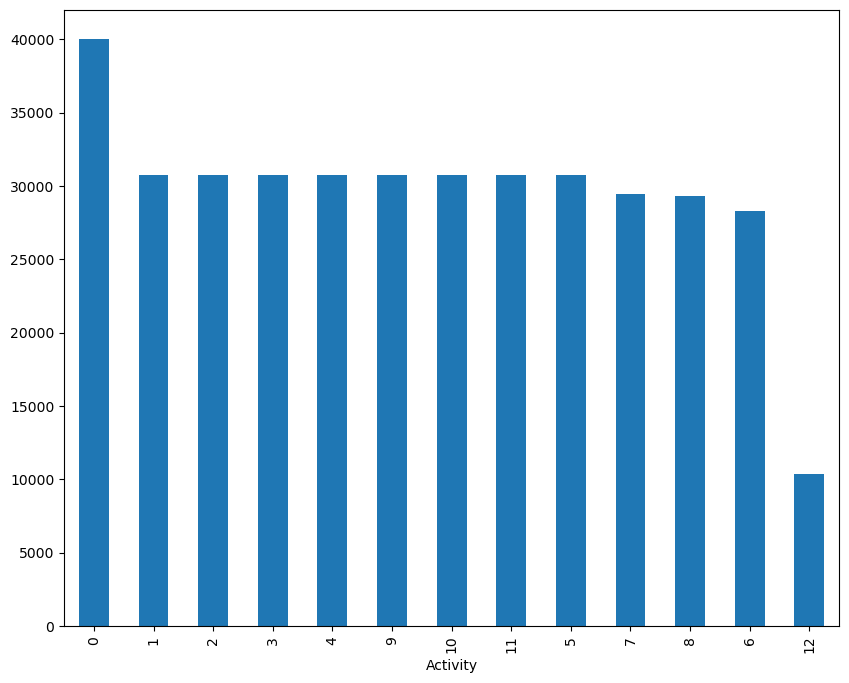

In [17]:
plt.figure(figsize=(10,8))
df["Activity"].value_counts().plot.bar()

In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
alx,383195.0,1.760210,4.163536,-22.1460,0.15910,1.36280,2.868500,20.0440
aly,383195.0,-9.153333,5.069422,-19.6190,-10.08400,-9.60940,-7.814500,21.1610
alz,383195.0,-0.739686,6.327115,-19.3730,-3.34630,0.28366,1.741000,25.0150
glx,383195.0,0.085659,0.464720,-1.8720,-0.35993,0.17811,0.482370,1.8701
gly,383195.0,-0.559553,0.424958,-7.7899,-0.81238,-0.69043,-0.493430,2.0113
glz,383195.0,-0.126797,0.554782,-2.6267,-0.57367,-0.11395,0.347740,1.9941
arx,383195.0,-3.488032,5.740895,-22.3450,-5.20310,-2.55170,-0.620985,19.8010
ary,383195.0,-5.779397,6.469414,-18.9720,-9.53580,-7.69800,-2.372650,22.0180
arz,383195.0,2.386581,4.134361,-18.2380,0.13928,1.83710,5.275150,25.7410
grx,383195.0,-0.212680,0.547046,-8.3392,-0.68627,-0.30980,0.237250,3.2745


## Data Preprocessing Summary

- Duplicate Removal: Performed df.duplicated().sum() to verify data integrity, ensuring no identical sensor readings were skewing the model.

- Imbalance Analysis: Initial exploration revealed a significant class imbalance where "Activity 0" dominated the dataset, potentially biasing any trained model toward a single class.

- Downsampling: To mitigate this bias, the majority class ("Activity 0") was filtered and randomly downsampled to 40,000 instances.

- Reconstruction: Using pd.concat, the downsampled majority class was merged with the remaining activity classes to create a balanced dataset, ensuring the model receives a more representative distribution of all physical activities.

# Step3: Exploratory Data Analysis EDA

In [19]:
activity_label = {
    0: "None",
    1: "Standing still (1 min)",
    2: "Sitting and relaxing (1 min)",
    3: "Lying down (1 min)",
    4: "Walking (1 min)",
    5: "Climbing stairs (1 min)",
    6: "Waist bends forward (20x)",
    7: "Frontal elevation of arms (20x)",
    8: "Knees bending (crouching) (20x)",
    9: "Cycling (1 min)",
    10: "Jogging (1 min)",
    11: "Running (1 min)",
    12: "Jump front & back (20x)"
}


================== Standing still (1 min) - a ====================


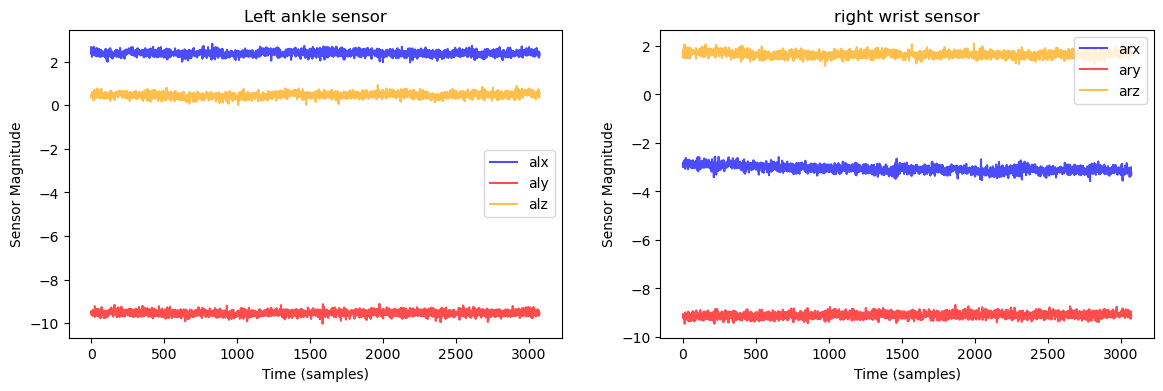

================== Standing still (1 min) - g ====================


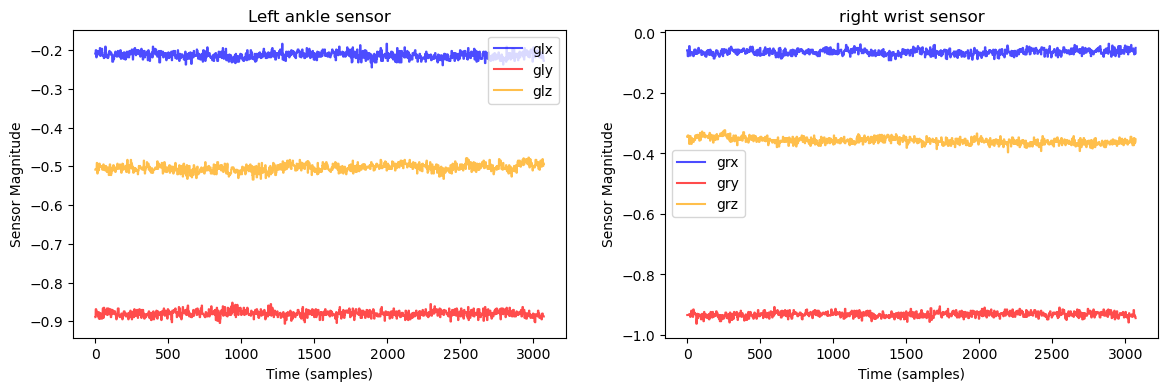

================== Sitting and relaxing (1 min) - a ====================


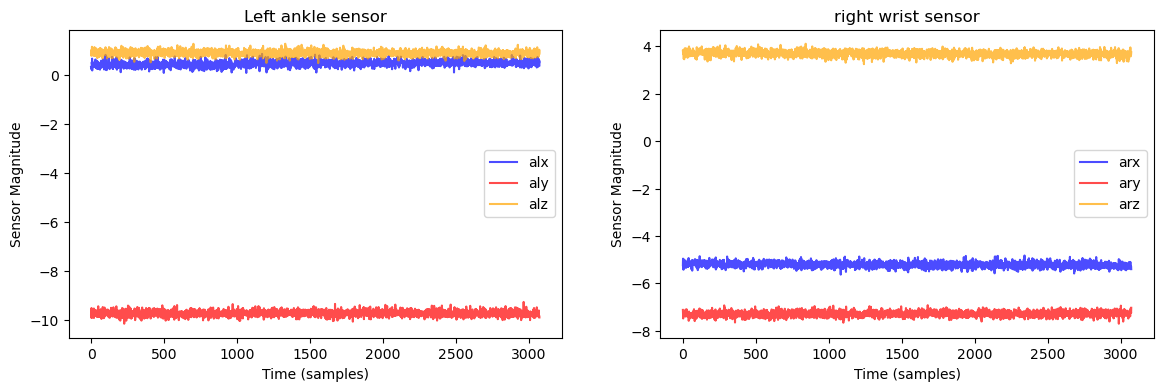

================== Sitting and relaxing (1 min) - g ====================


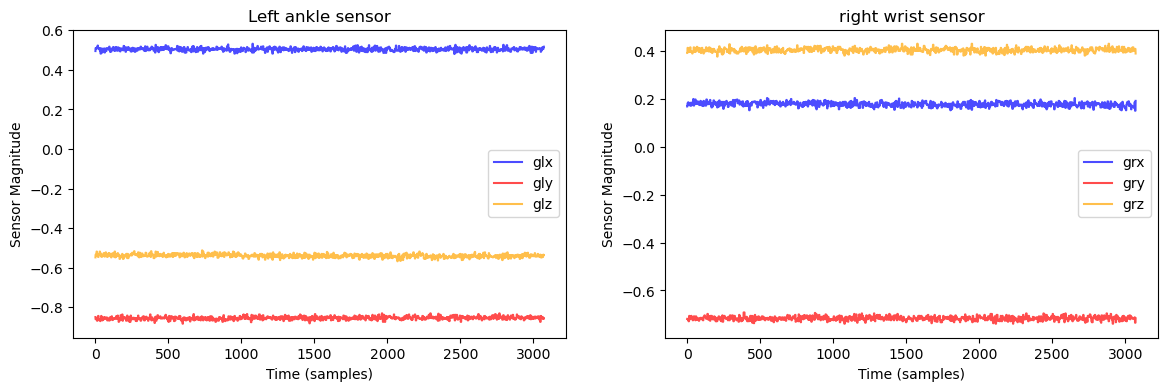

================== Lying down (1 min) - a ====================


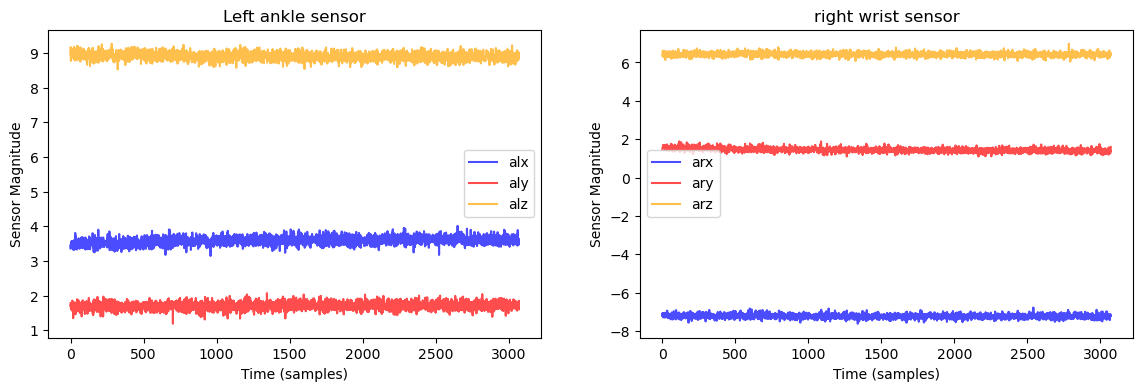

================== Lying down (1 min) - g ====================


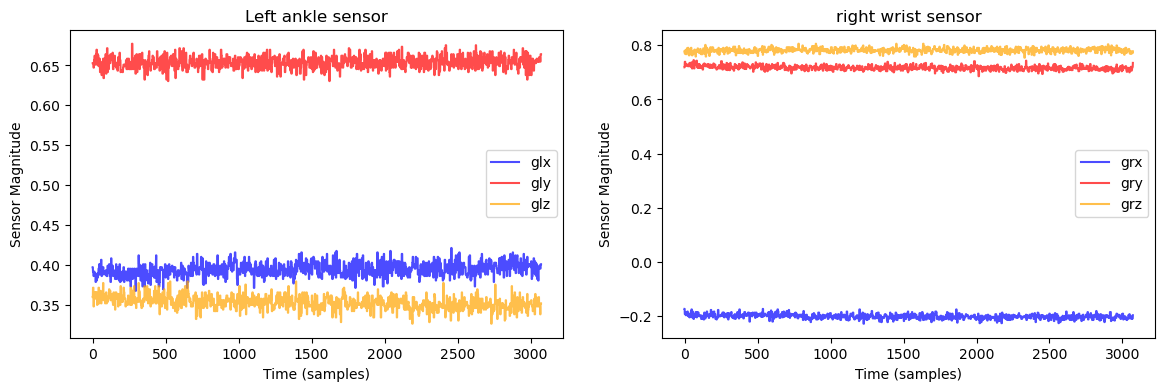

================== Walking (1 min) - a ====================


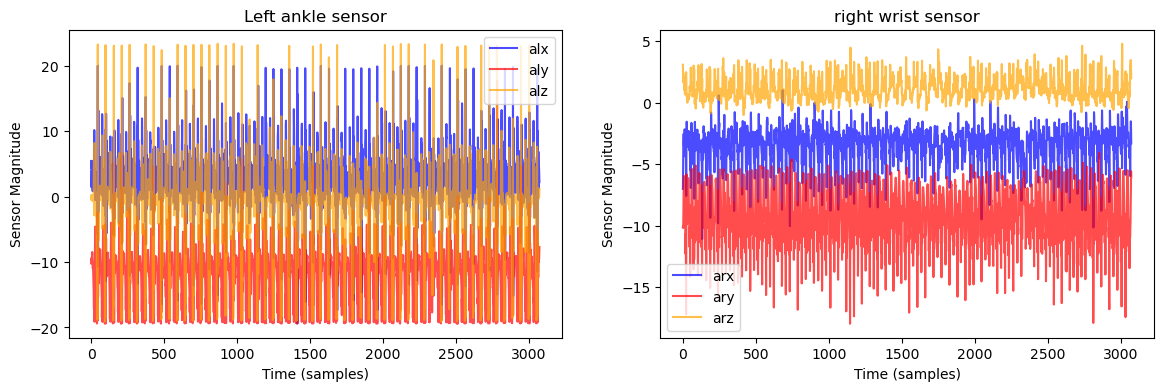

================== Walking (1 min) - g ====================


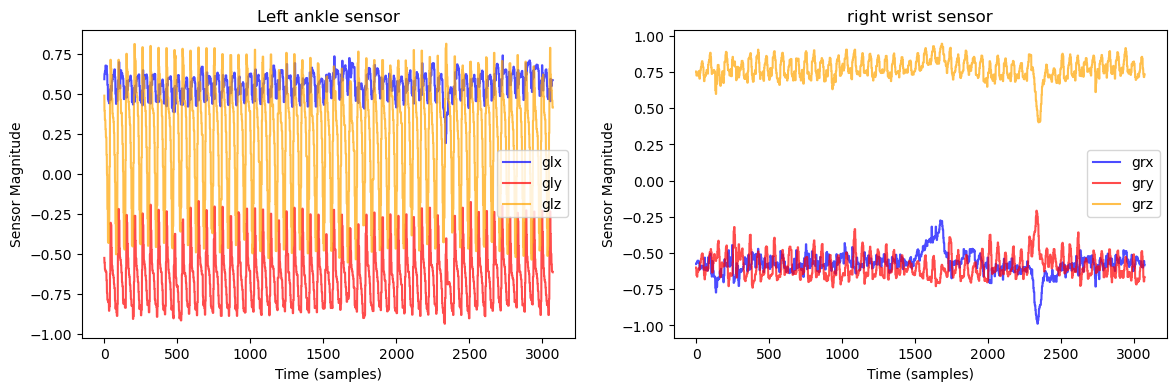

================== Climbing stairs (1 min) - a ====================


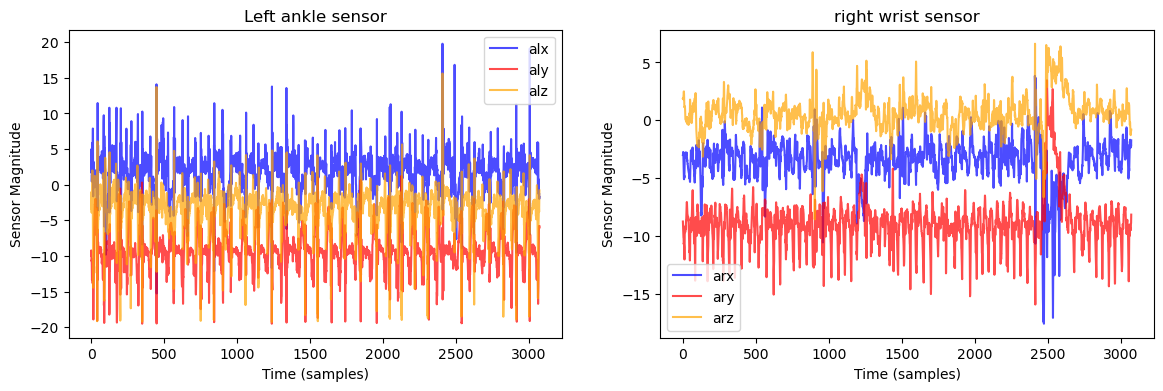

================== Climbing stairs (1 min) - g ====================


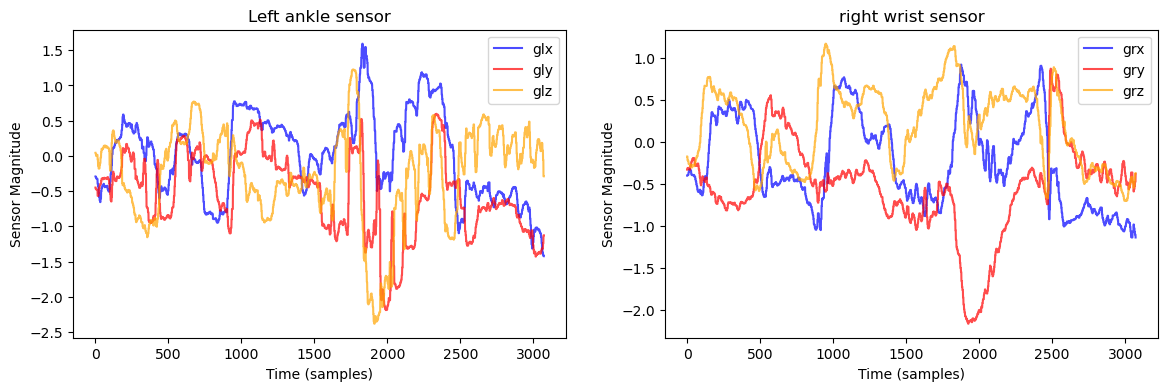

================== Waist bends forward (20x) - a ====================


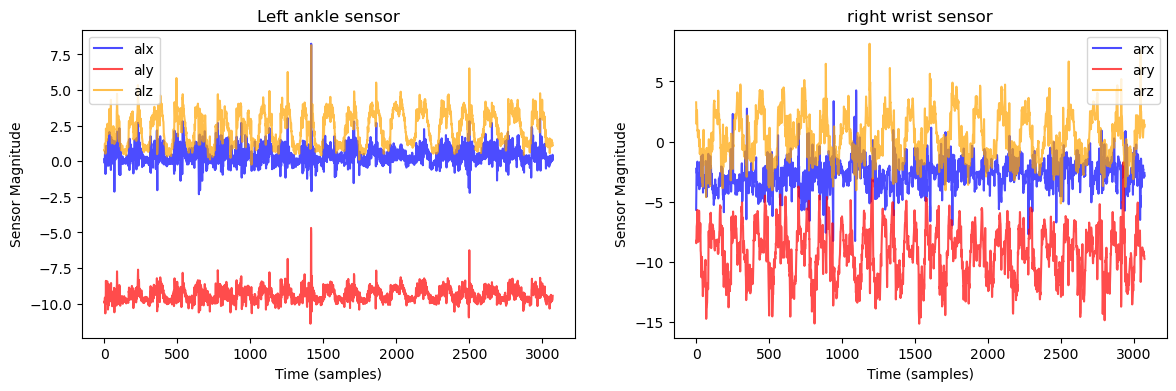

================== Waist bends forward (20x) - g ====================


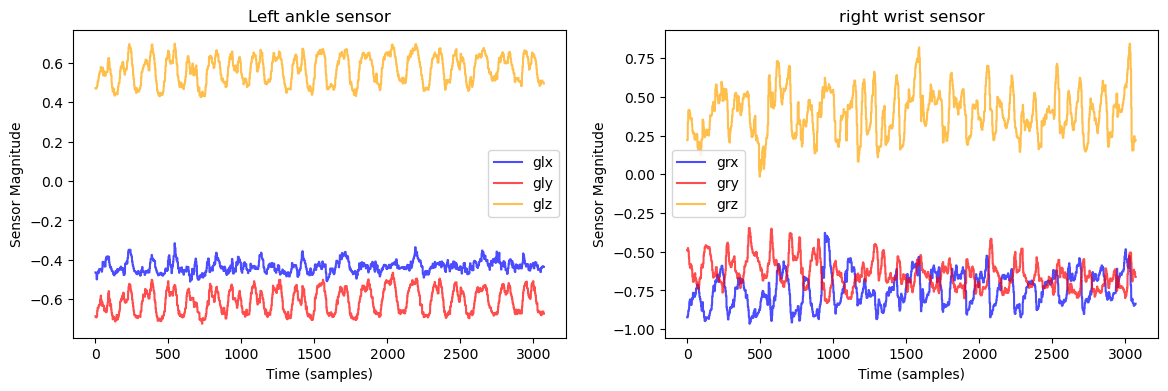

================== Frontal elevation of arms (20x) - a ====================


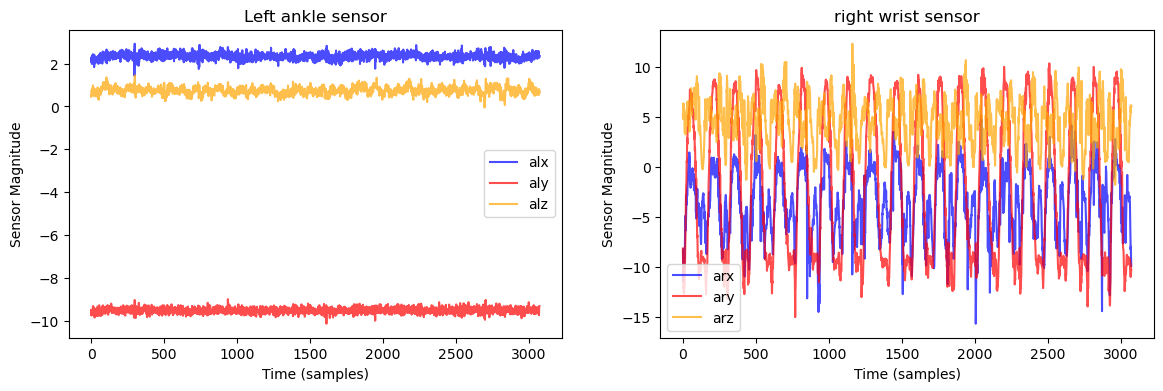

================== Frontal elevation of arms (20x) - g ====================


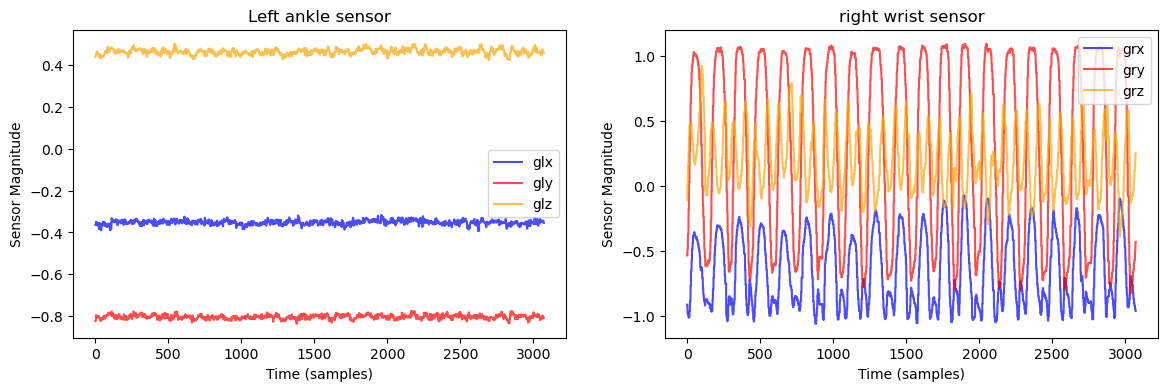

================== Knees bending (crouching) (20x) - a ====================


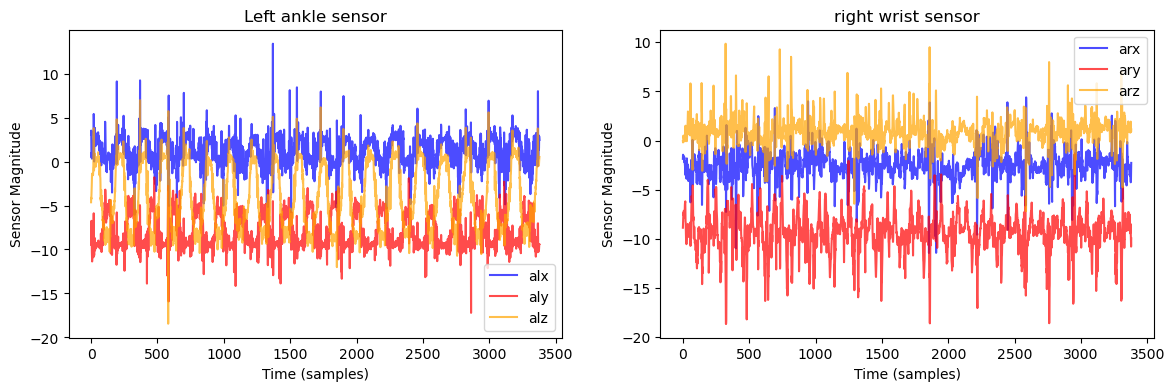

================== Knees bending (crouching) (20x) - g ====================


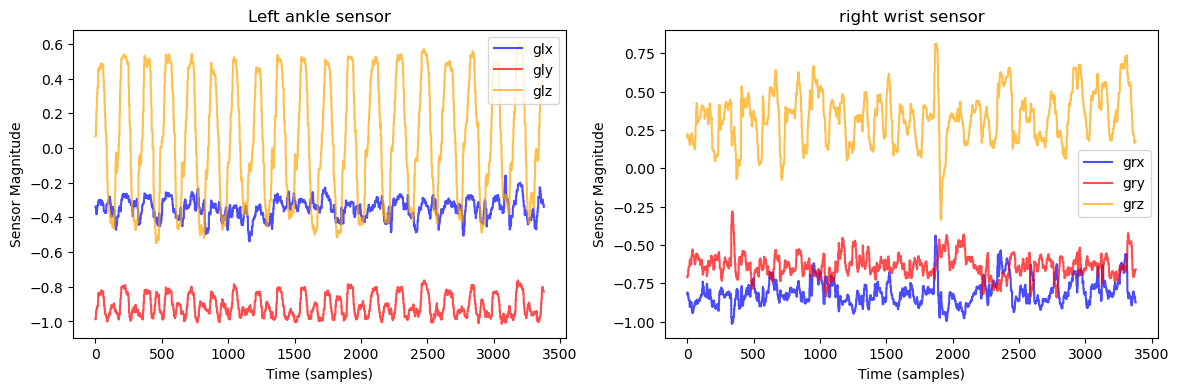

================== Cycling (1 min) - a ====================


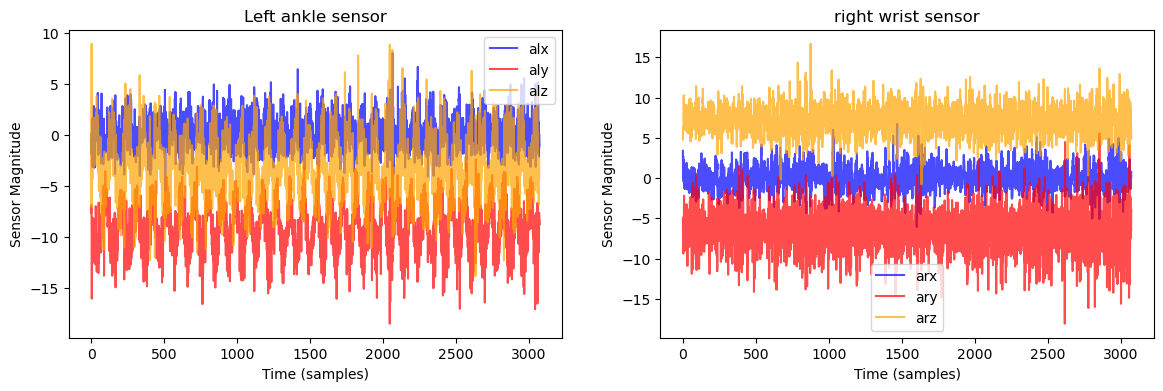

================== Cycling (1 min) - g ====================


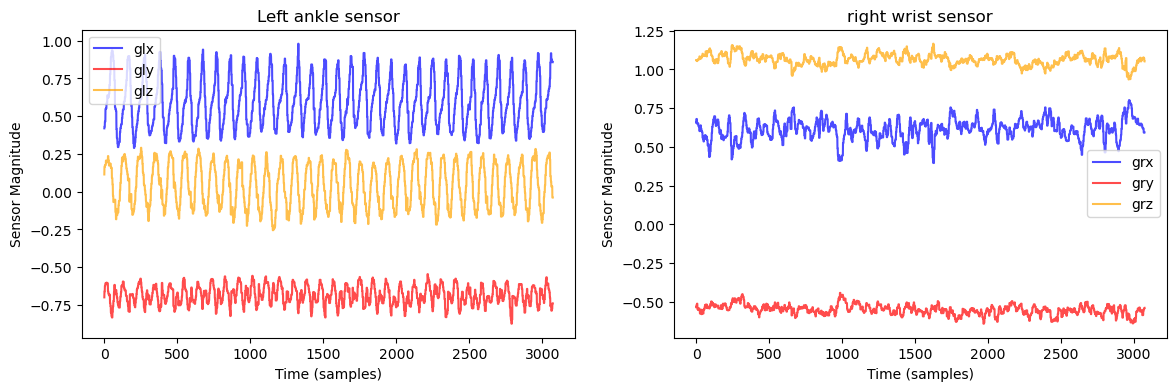

================== Jogging (1 min) - a ====================


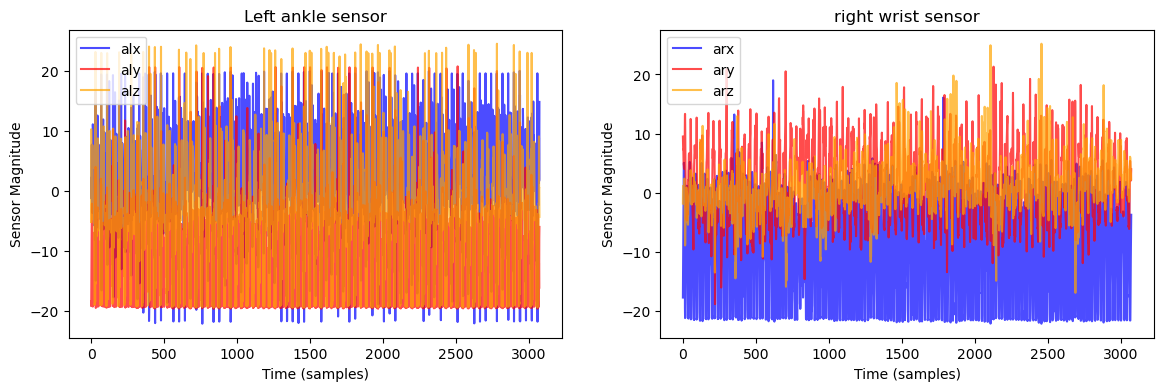

================== Jogging (1 min) - g ====================


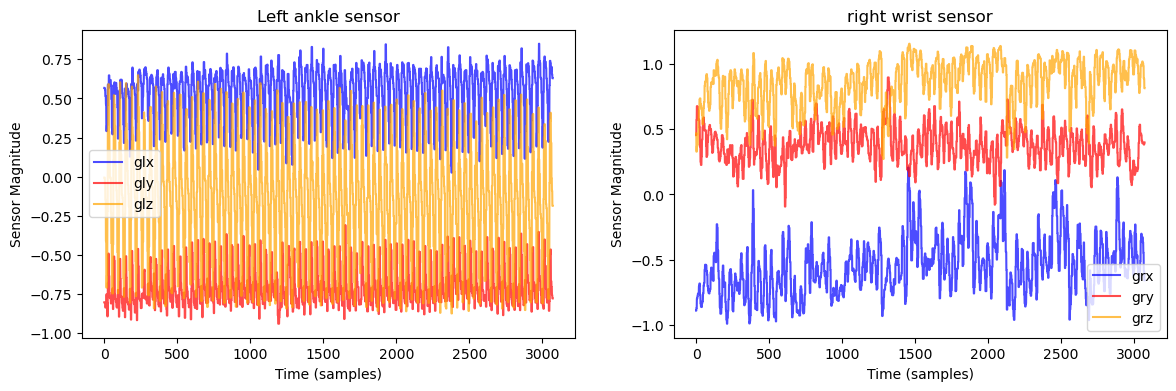

================== Running (1 min) - a ====================


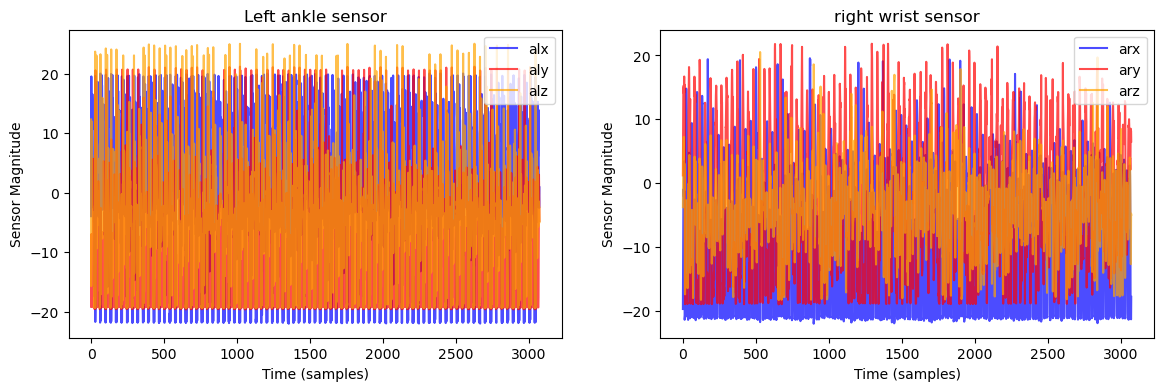

================== Running (1 min) - g ====================


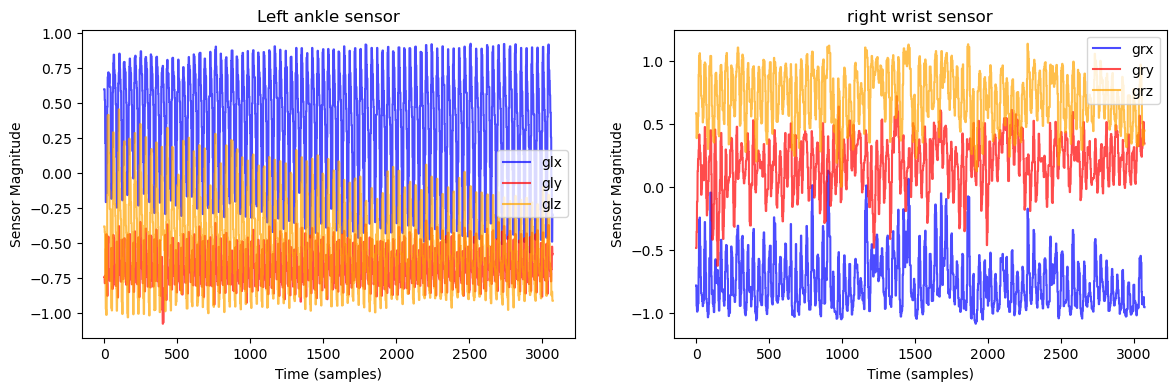

================== Jump front & back (20x) - a ====================


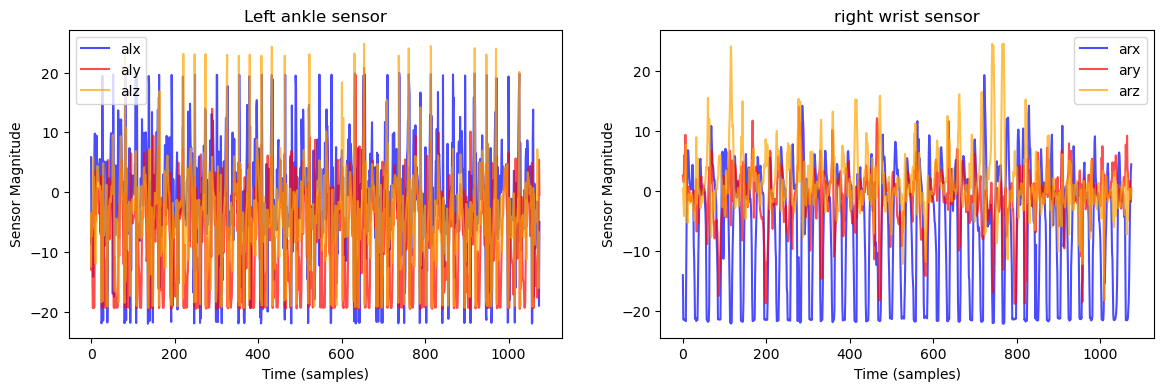

================== Jump front & back (20x) - g ====================


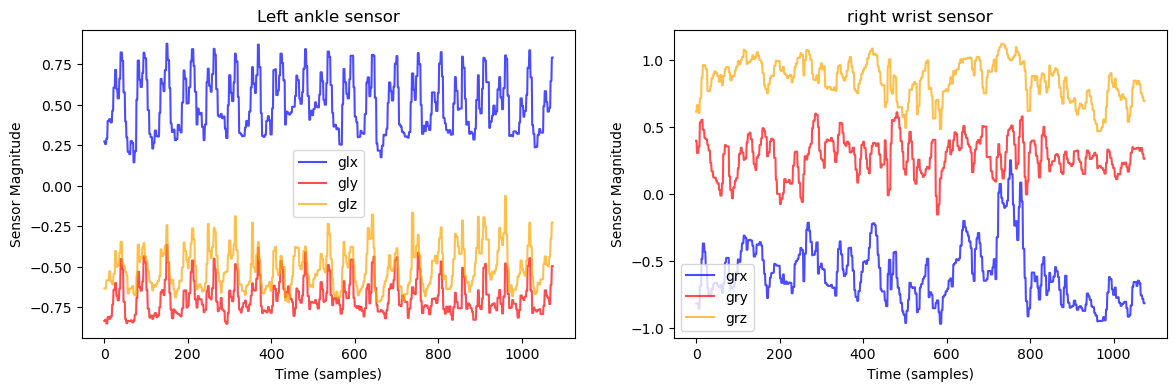

In [20]:
subject1 = df[df['subject'] == 'subject1']
readings = ['a', 'g']

for i in range(1, 13):
    for r in readings:
        print(f"================== {activity_label[i]} - {r} ====================")
        plt.figure(figsize=(14, 4))
        
        plt.subplot(1, 2, 1)
        plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "lx"],
                 color='blue', alpha=0.7, label=r + "lx")
        plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "ly"],
                 color='red', alpha=0.7, label=r + "ly")
        plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "lz"],
                 color='orange', alpha=0.7, label=r + "lz")
        plt.title("Left ankle sensor")
        plt.xlabel("Time (samples)") # New label
        plt.ylabel("Sensor Magnitude") # New label
        
        plt.legend()
        
        plt.subplot(1, 2, 2)
        plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "rx"],
                 color='blue', alpha=0.7, label=r + "rx")
        plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "ry"],
                 color='red', alpha=0.7, label=r + "ry")
        plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "rz"],
                 color='orange', alpha=0.7, label=r + "rz")
        plt.title("right wrist sensor")
        plt.xlabel("Time (samples)") # New label
        plt.ylabel("Sensor Magnitude") # New label
        
        plt.legend()
        plt.show()

By visualizing these plots, we are performing a visual inspection to understand how different physical activities appear as sensor signals.

## Summary of the Conclusion

- Feature Characterization: The plots allows to observe how specific activities, like "Running" or "Walking," create unique wave patterns in the acceleration ('a') and rotational ('g') sensor data.

- Activity Differentiation: By comparing the X, Y, and Z axis readings (the blue, red, and orange lines), one can distinguish between rhythmic activities (like cycling) and erratic ones (like jumping).

- Model Readiness: This visualization confirms that the sensor features have distinct signatures, which is essential for your classification models (like RandomForest or SVC) to learn how to categorize the data correctly.

- Quality Control: These plots help one spot potential anomalies or noise in the sensor data before one proceed to the training phase.

- Essentially, this code acts as a "sanity check" to ensure that the data you have collected captures the physical differences between activities clearly enough for an algorithm to learn them.



In [21]:
df['Activity'] = df['Activity'].replace([0,1,2,3,4,5,6,7,8,9,10,11,12],['None',
                                                                   'Standing still (1 min)',
                                                                   'Sitting and relaxing (1 min)',
                                                                   'Lying down (1 min)',
                                                                   'Walking (1 min)',
                                                                   'Climbing stairs (1 min)',
                                                                   'Waist bends forward (20x)',
                                                                   'Frontal elevation of arms (20x)',
                                                                   'Knees bending (crouching) (20x)',
                                                                   'Cycling (1 min)','Jogging (1 min)',
                                                                   'Running (1 min)','Jump front & back (20x)'])

df["Activity"]

24814                         None
900231                        None
2894                          None
520811                        None
929123                        None
                    ...           
1213641    Jump front & back (20x)
1213642    Jump front & back (20x)
1213643    Jump front & back (20x)
1213644    Jump front & back (20x)
1213645    Jump front & back (20x)
Name: Activity, Length: 383195, dtype: object

In [22]:
df["Activity"].value_counts()

Activity
None                               40000
Standing still (1 min)             30720
Sitting and relaxing (1 min)       30720
Lying down (1 min)                 30720
Walking (1 min)                    30720
Cycling (1 min)                    30720
Jogging (1 min)                    30720
Running (1 min)                    30720
Climbing stairs (1 min)            30720
Frontal elevation of arms (20x)    29441
Knees bending (crouching) (20x)    29337
Waist bends forward (20x)          28315
Jump front & back (20x)            10342
Name: count, dtype: int64

<Axes: ylabel='count'>

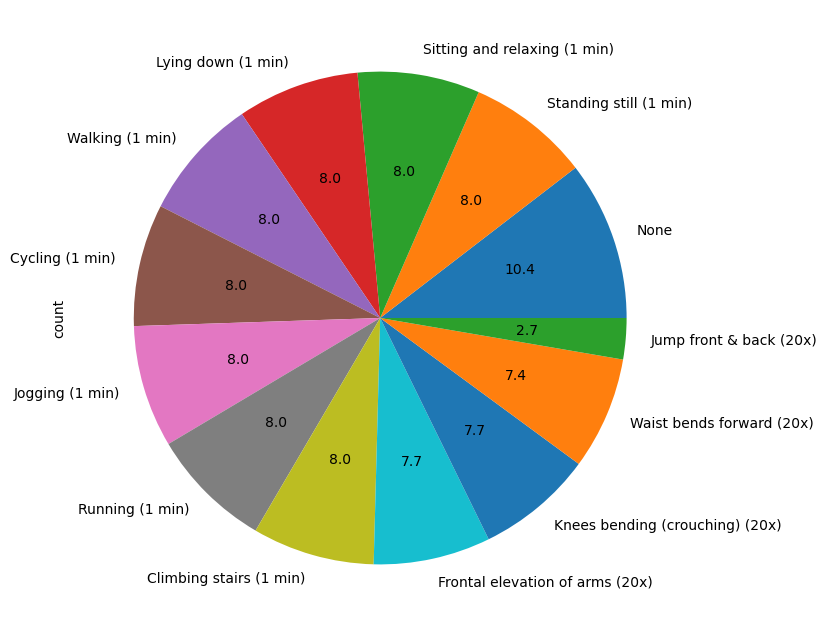

In [23]:
plt.figure(figsize=(12,8))
round(df["Activity"].value_counts()/df.shape[0]*100,2).plot.pie(autopct= "%2.1f")

## To get rid of outliers

In [24]:
df1=df.copy()

for feature in df1.columns[:-2]:
    lower_range=np.quantile(df[feature], 0.01)
    upper_range=np.quantile(df[feature],0.99)
    print(feature, "range", lower_range), "to", upper_range

    df1= df1.drop(df1[(df1[feature]>upper_range) | (df1[feature]<lower_range)].index,axis=0)
    print("shape",df1.shape)

alx range -11.52024
shape (375537, 14)
aly range -19.378
shape (369631, 14)
alz range -18.949
shape (365827, 14)
glx range -0.7551
shape (358772, 14)
gly range -1.0675
shape (351938, 14)
glz range -1.1061
shape (346234, 14)
arx range -21.488000000000003
shape (341020, 14)
ary range -18.691
shape (334803, 14)
arz range -10.245
shape (332133, 14)
grx range -1.0216
shape (328500, 14)
gry range -1.1437
shape (323467, 14)
grz range -0.70905
shape (318810, 14)


In [25]:
df1

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
24814,3.70640,-9.74610,-1.3461,-0.51763,-0.82176,0.241650,-4.0970,-8.193700,-0.36802,-0.766670,-0.71663,-0.256470,None,subject1
900231,1.42950,-10.01800,-1.7574,0.48980,-1.06190,-0.066798,-1.0573,-8.927800,1.22030,-0.180390,-1.02670,0.629310,None,subject8
2894,0.53984,0.56876,-0.5495,-0.33395,-0.78799,-0.636540,1.3400,0.242520,-1.74830,0.035294,-0.98152,-0.418100,None,subject1
520811,0.44736,-9.80920,1.2536,0.23191,-0.62477,0.569740,-5.0885,-1.213100,9.68930,0.345100,-0.22177,1.023700,None,subject4
929123,4.42850,-9.08880,-1.9518,-0.14657,-0.66604,-0.793710,-6.8718,-3.487800,9.22140,-0.162750,-0.96304,-0.084052,None,subject8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1213636,-0.19979,-0.93484,2.5554,0.63080,-0.52533,-0.679760,-4.0212,-0.082645,0.73545,-0.458820,-1.00000,0.122840,Jump front & back (20x),subject10
1213637,-0.33315,-1.23710,-2.9194,0.63822,-0.42777,-0.748530,-2.2515,-0.414790,0.52093,-0.417650,-1.03700,0.088362,Jump front & back (20x),subject10
1213640,6.77570,-15.07500,7.3974,0.61967,-0.33771,-0.827110,-2.2797,-2.358900,2.11120,-0.417650,-1.03700,0.088362,Jump front & back (20x),subject10
1213641,-2.48730,-19.23300,3.4614,0.61967,-0.33771,-0.827110,-8.2348,-4.965200,2.48090,-0.437250,-1.01850,0.079741,Jump front & back (20x),subject10


# Step4: Data Propressing

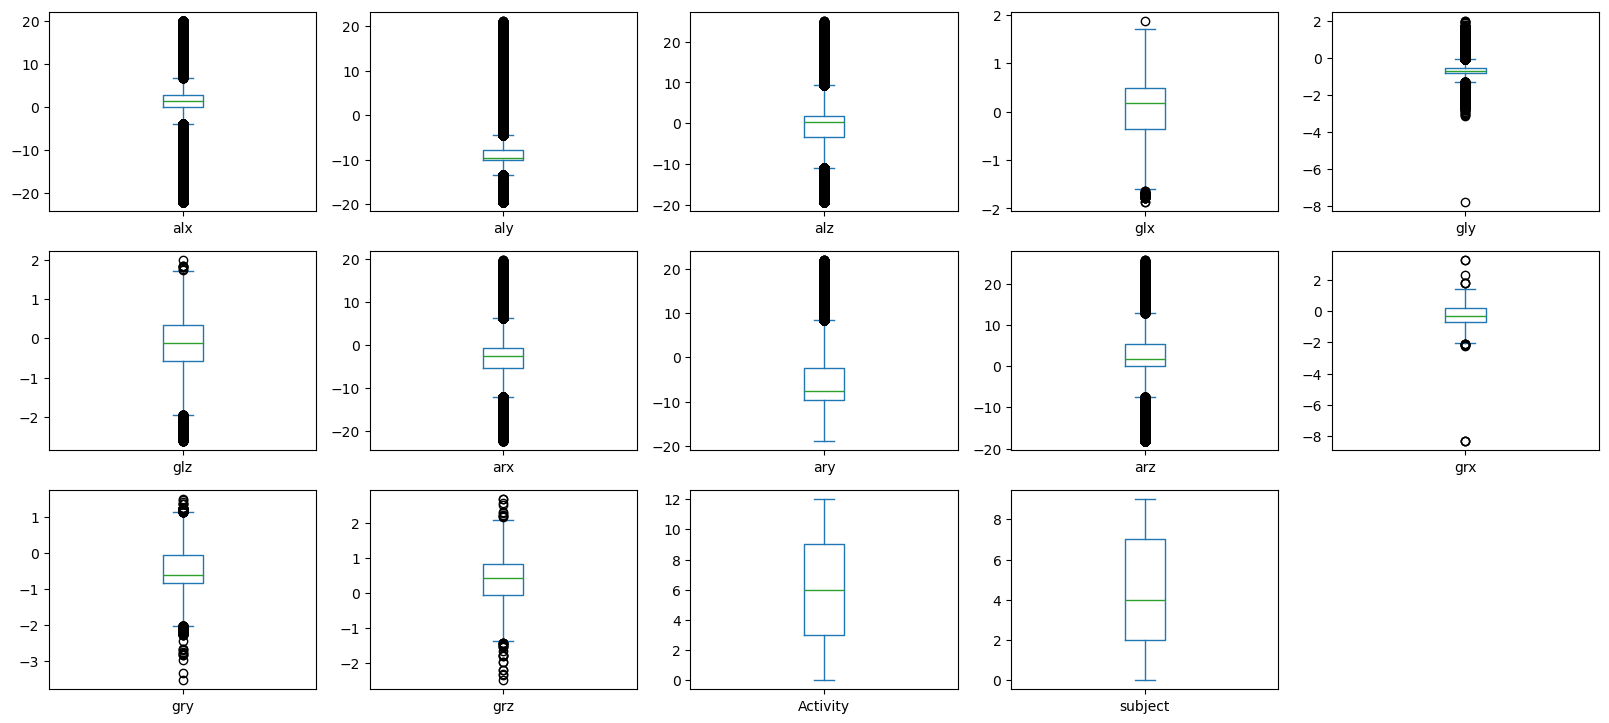

In [26]:
le = LabelEncoder()
df['subject'] = le.fit_transform(df['subject'])

df['Activity'] = le.fit_transform(df['Activity'])

df.plot(kind='box', subplots=True, layout=(5,5), figsize=(20,15))
plt.show()

In [27]:
X= df.drop(["Activity","subject"],axis=1).values
y=df["Activity"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,random_state=42)


In [28]:
ro_scaler = RobustScaler().fit(X_train)
X_train_scaled = ro_scaler.transform(X_train)
X_test_scaled = ro_scaler.transform(X_test)

# Step5: Building Model

In [38]:
def resultsSummarizer(y_true,y_pred,cme=True):
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')

    if cme:
        plt.figure(figsize=(15,15))
        sns.heatmap(cm,annot=True, cmap="Blues", xticklabels=activity_label.values(),yticklabels=activity_label.values())
        plt.title("Confusion Matrix")
        plt.show()

    print(f'Accuracy Score: ' + '{:.4%}'.format(acc))
    print(f'Precision Score: ' + '{:.4%}'.format(prec))
    print(f'Recall Score: ' + '{:.4%}'.format(rec))
    print(f'F1 Score: ' + '{:.4%}'.format(f1))
    

In [ ]:

def modeltrain(md,md2):
   
    
    
    md.fit(X_train,y_train)
    md2.fit(X_train_scaled,y_train)
    
    print()
    print("#"*80)
    print("Using Model ",type(md).__name__)
    print("Training score: ",md.score(X_train,y_train))
    print("\nAfter Scaled features:\nTraining score: ",md2.score(X_train_scaled,y_train))
    print()
    print("#"*80)
    
    return md, md2
    
def modeltest(md,md2,flag=True)   : 
    print()
    print("#"*80)
    
    print("Test score: ",md.score(X_test,y_test))
    y_pred=md.predict(X_test) 
    
    print("\nAfter Scaled features: \nTest score:",md2.score(X_test_scaled,y_test))
    y_pred_scaled=md2.predict(X_test_scaled)
    
    print("#"*80)

    resultsSummarizer( y_test,y_pred,flag )
    resultsSummarizer( y_test,y_pred_scaled)
    
 

### 1. LogisticResgression

In [47]:
lr=LogisticRegression(max_iter=500)
lr_scaled=LogisticRegression(max_iter=500)

m1,m2=modeltrain(lr,lr_scaled)

C:\Users\aarti\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



################################################################################
Using Model  LogisticRegression
Training score:  0.5507731492435525

After Scaled features:
Training score:  0.5517508942365238

################################################################################



################################################################################
Test score:  0.551738535892859

After Scaled features: 
Test score: 0.5526258102902953
################################################################################


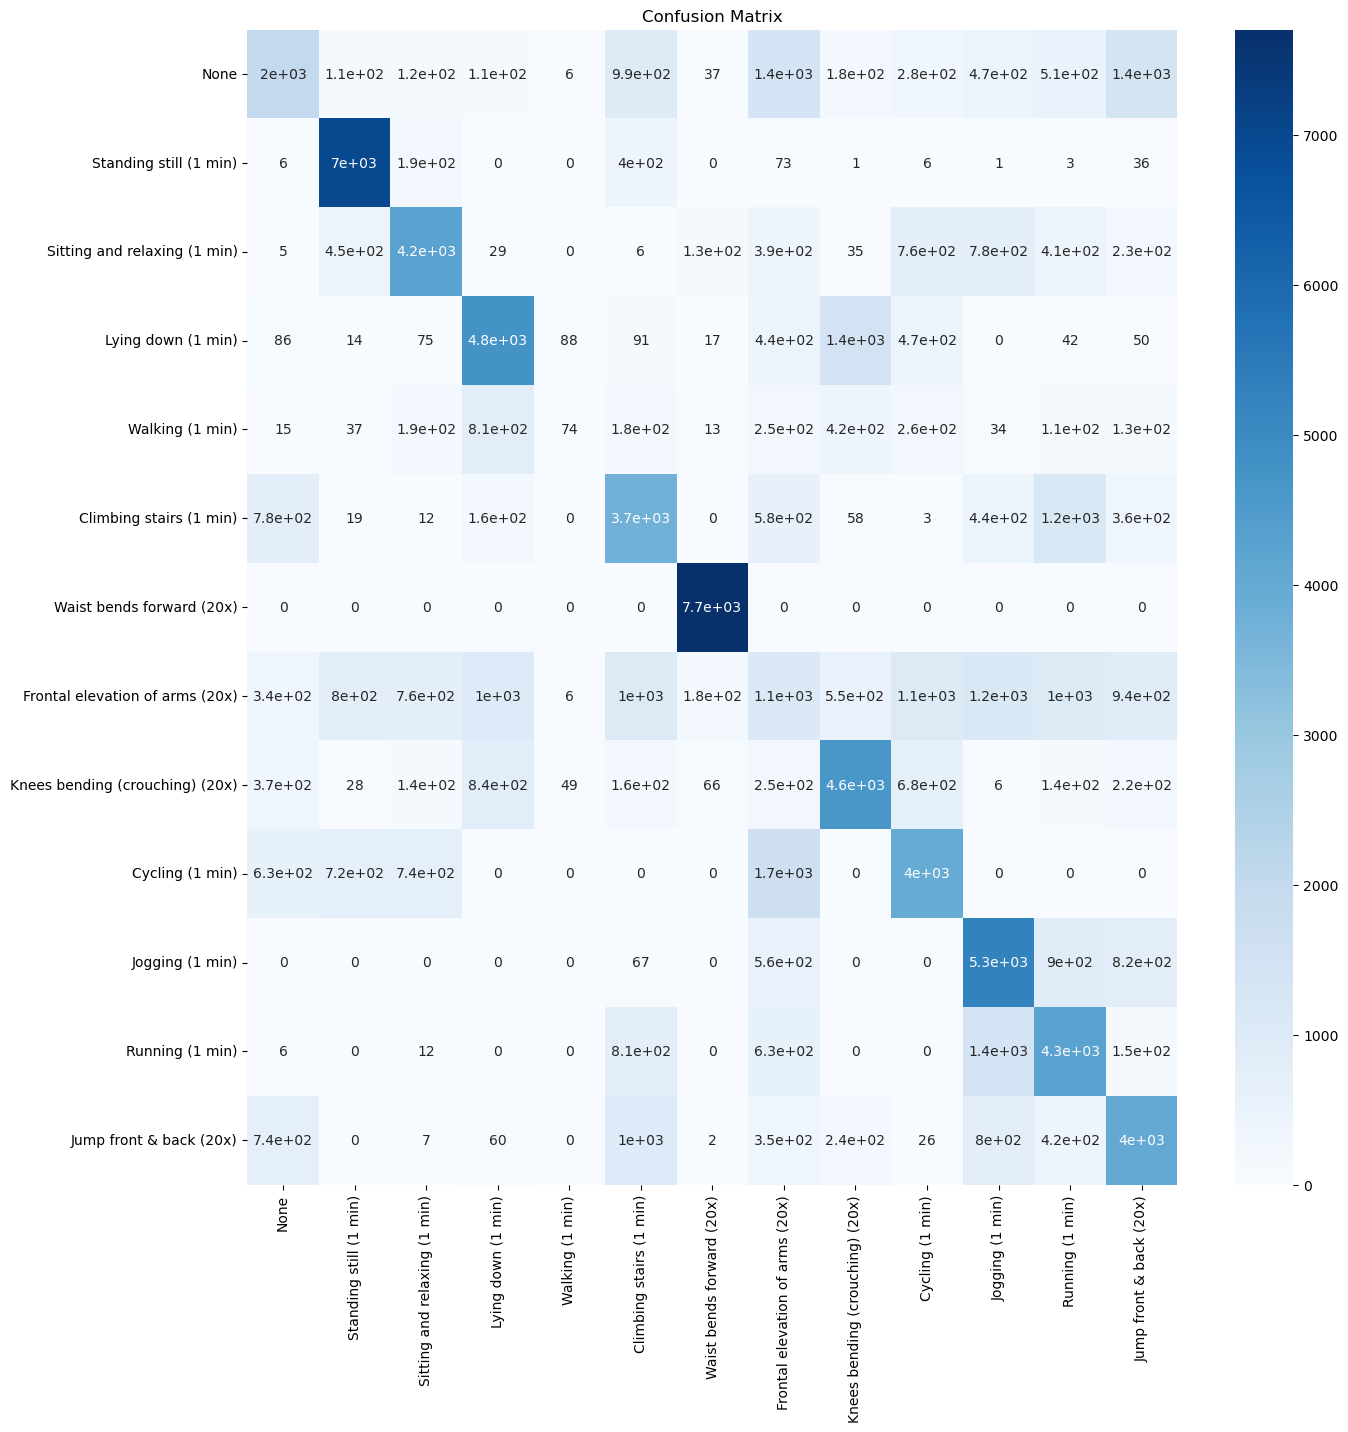

Accuracy Score: 55.1739%
Precision Score: 53.0976%
Recall Score: 53.4793%
F1 Score: 51.9242%


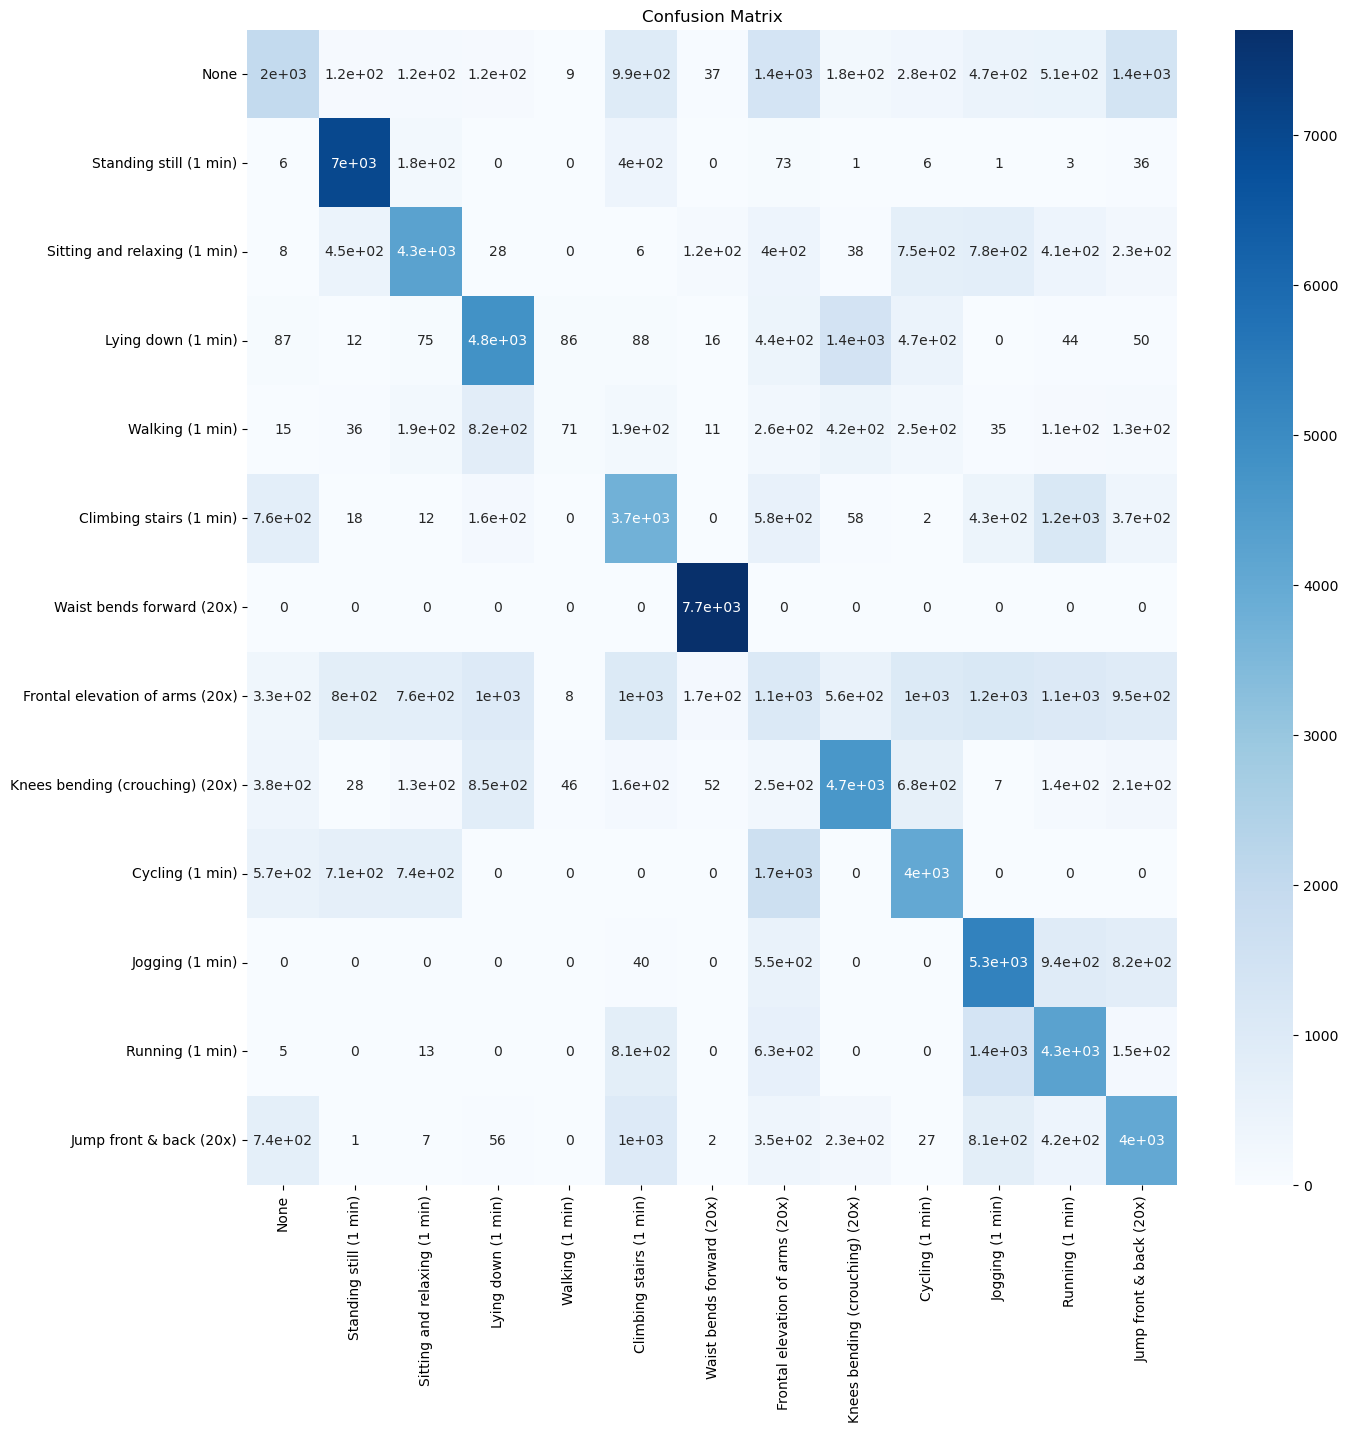

Accuracy Score: 55.2626%
Precision Score: 53.1290%
Recall Score: 53.5569%
F1 Score: 51.9878%


In [46]:
modeltest(m1,m2)

### 2. KNN

In [48]:
knn1 = KNeighborsClassifier(n_neighbors=5)
knn2=KNeighborsClassifier(n_neighbors=5)
k1,k2=modeltrain(knn1,knn2)


################################################################################
Using Model  KNeighborsClassifier
Training score:  0.9153989617113669

After Scaled features:
Training score:  0.9524419268187448

################################################################################


The darker the shade of diagonal row in the confusion matrix the better the model is.


################################################################################
Test score:  0.8873265900479128

After Scaled features: 
Test score: 0.9384857879518576
################################################################################


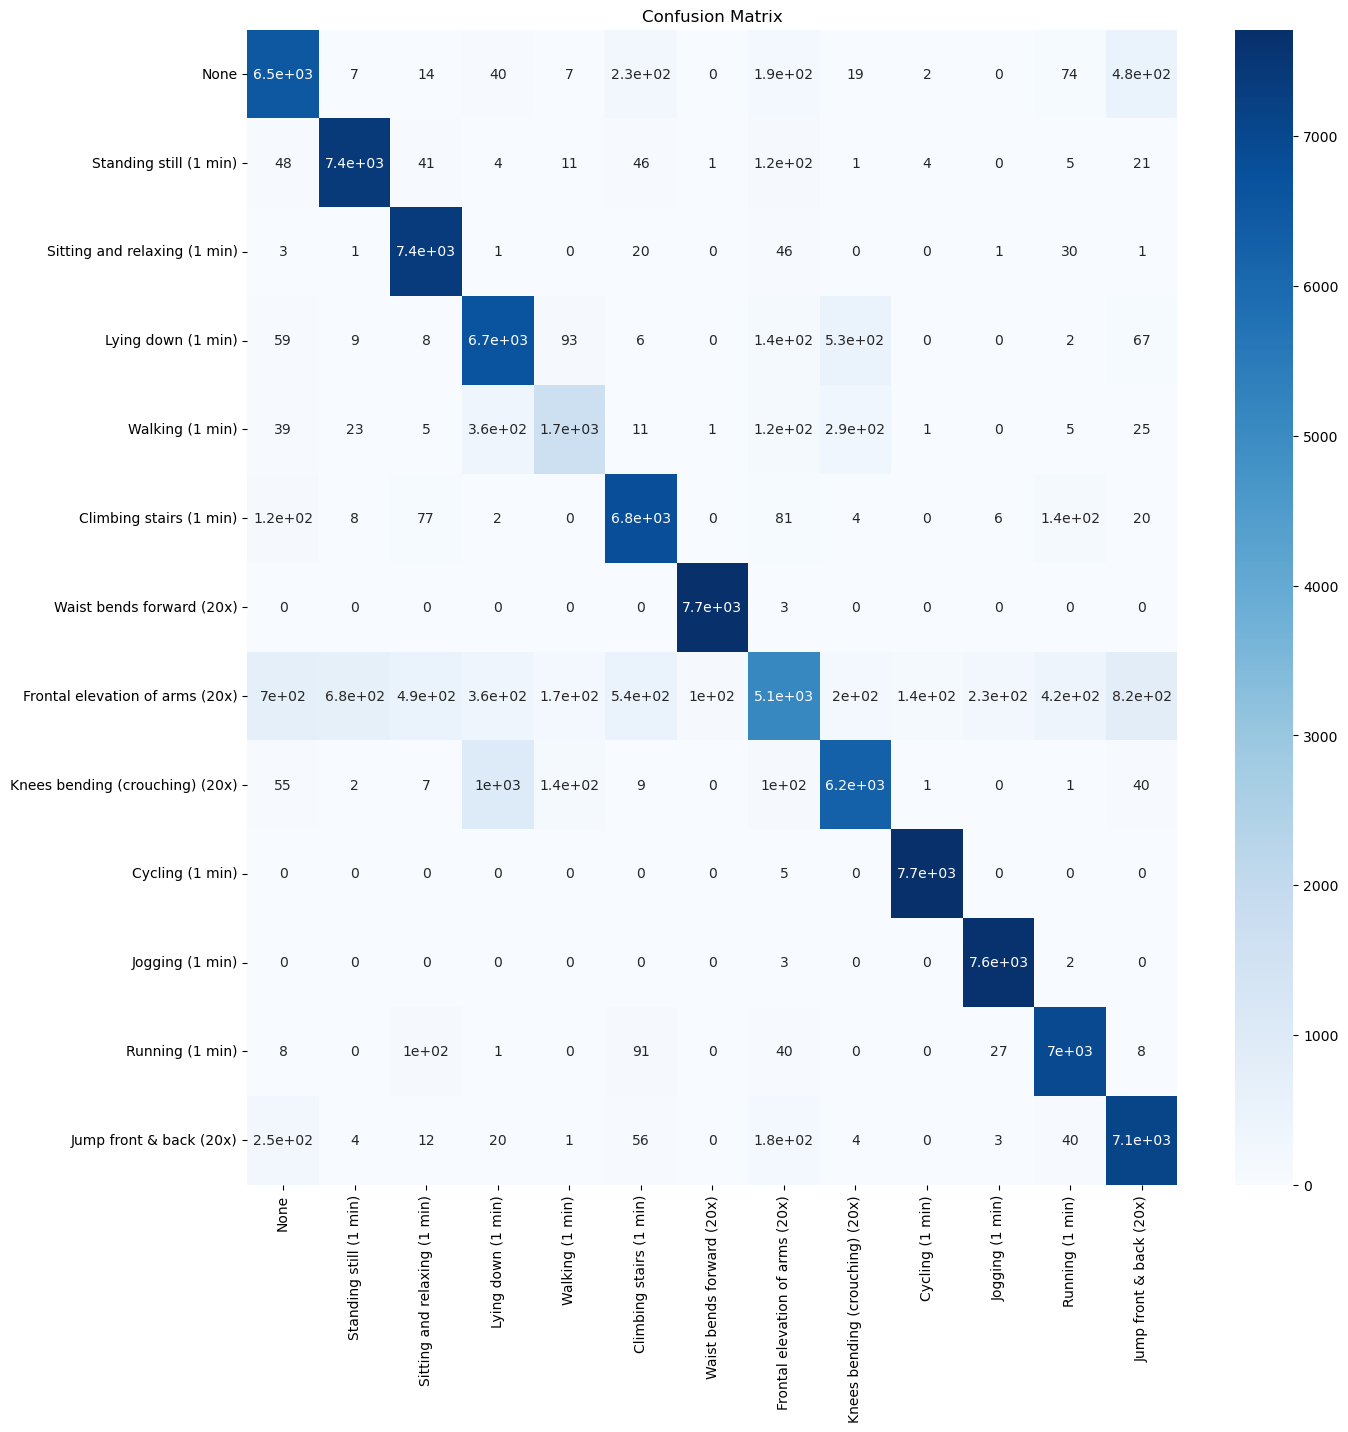

Accuracy Score: 88.7327%
Precision Score: 88.2094%
Recall Score: 88.4496%
F1 Score: 87.9053%


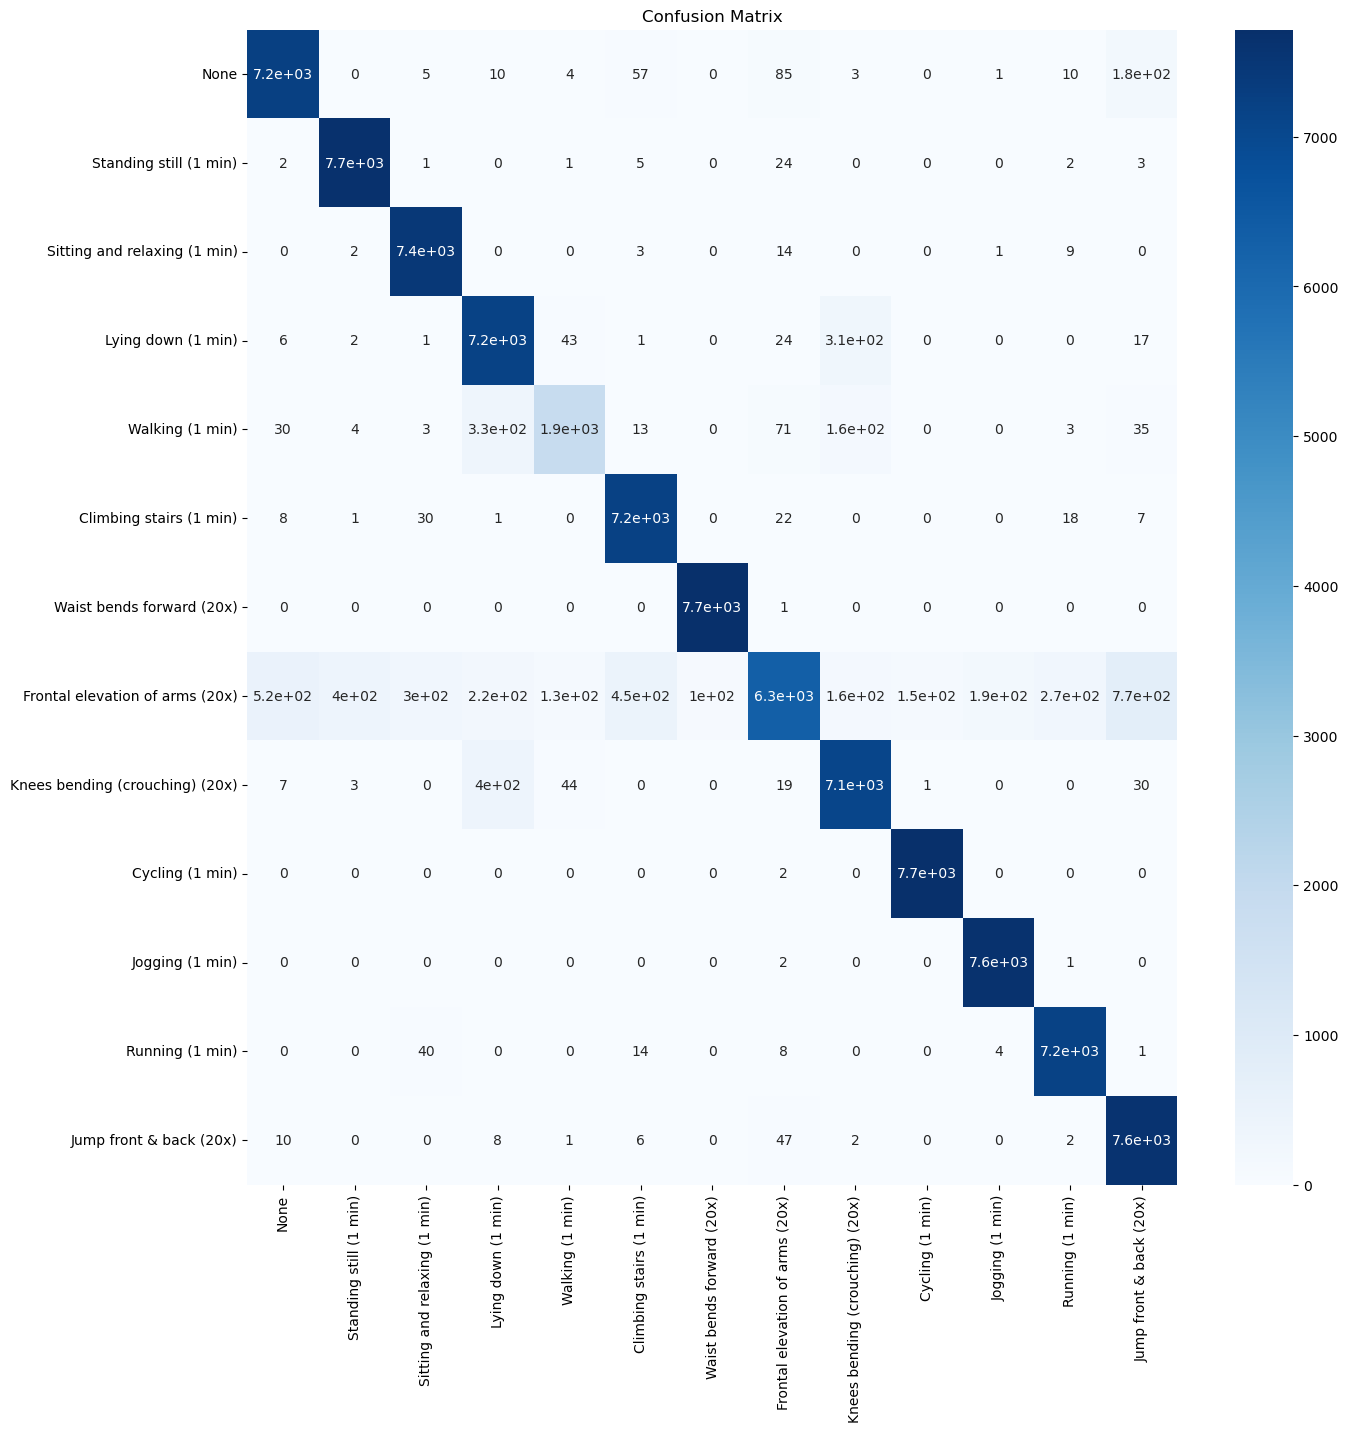

Accuracy Score: 93.8486%
Precision Score: 93.6709%
Recall Score: 93.5941%
F1 Score: 93.2747%


In [50]:
# testing the model
modeltest(k1,k2)

In [52]:
# Initialize a list to keep track of F1 scores
f1_scores = []

for n in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    
    # Calculate and store the f1_score for the current n
    # Note: Ensure your resultsSummarizer returns the f1 score
    score = f1_score(y_test, y_pred, average='macro')
    f1_scores.append(score)
    
    print(f"\n================No of Neighbors: {n}================\n")
    resultsSummarizer(y_test, y_pred, cme=False)

# Find the maximum F1 score and the corresponding n value
max_f1 = max(f1_scores)
best_n = f1_scores.index(max_f1) + 1

print(f"\n================Summary================\n")
print(f"Maximum F1 Score: {max_f1:.4%}")
print(f"Best number of neighbors (n): {best_n}")
    


================No of Neighbors: 1================

Accuracy Score: 94.0511%
Precision Score: 93.7674%
Recall Score: 93.8098%
F1 Score: 93.6877%

================No of Neighbors: 2================

Accuracy Score: 93.4227%
Precision Score: 93.1073%
Recall Score: 93.2417%
F1 Score: 92.9847%

================No of Neighbors: 3================

Accuracy Score: 94.1899%
Precision Score: 94.0043%
Recall Score: 94.0042%
F1 Score: 93.7028%

================No of Neighbors: 4================

Accuracy Score: 93.9519%
Precision Score: 93.7772%
Recall Score: 93.7422%
F1 Score: 93.4334%

================No of Neighbors: 5================

Accuracy Score: 93.8486%
Precision Score: 93.6709%
Recall Score: 93.5941%
F1 Score: 93.2747%

================No of Neighbors: 6================

Accuracy Score: 93.6607%
Precision Score: 93.5265%
Recall Score: 93.3562%
F1 Score: 93.0436%

================No of Neighbors: 7================

Accuracy Score: 93.5928%
Precision Score: 93.4632%
Recall Score: 93.297

### 3. DecisionTreeClassifier

In [54]:
tc1 = DecisionTreeClassifier(max_depth=14)
tc2=DecisionTreeClassifier(max_depth=14)
t1,t2=modeltrain(tc1,tc2)


################################################################################
Using Model  DecisionTreeClassifier
Training score:  0.8928795111970939

After Scaled features:
Training score:  0.8928829907166419

################################################################################



################################################################################
Test score:  0.8711573189699267

After Scaled features: 
Test score: 0.8708859173895344
################################################################################


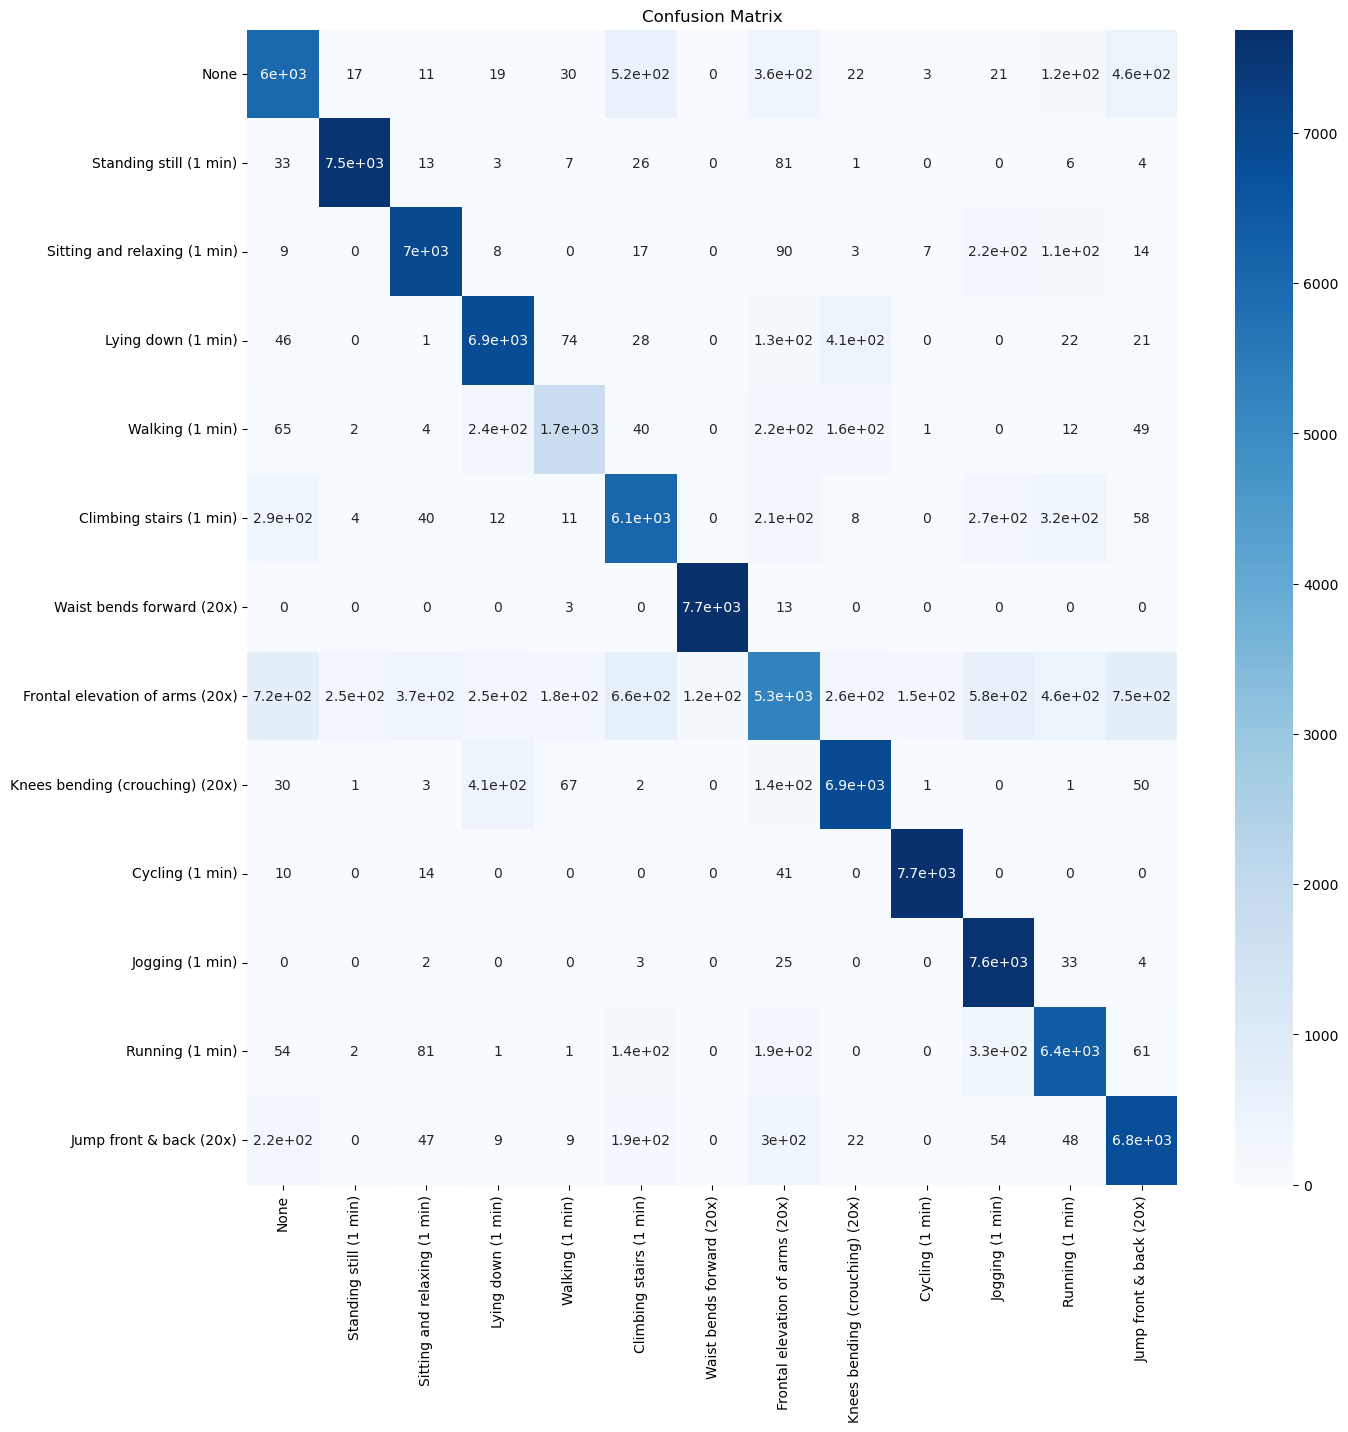

Accuracy Score: 87.1157%
Precision Score: 86.7707%
Recall Score: 86.9447%
F1 Score: 86.5966%


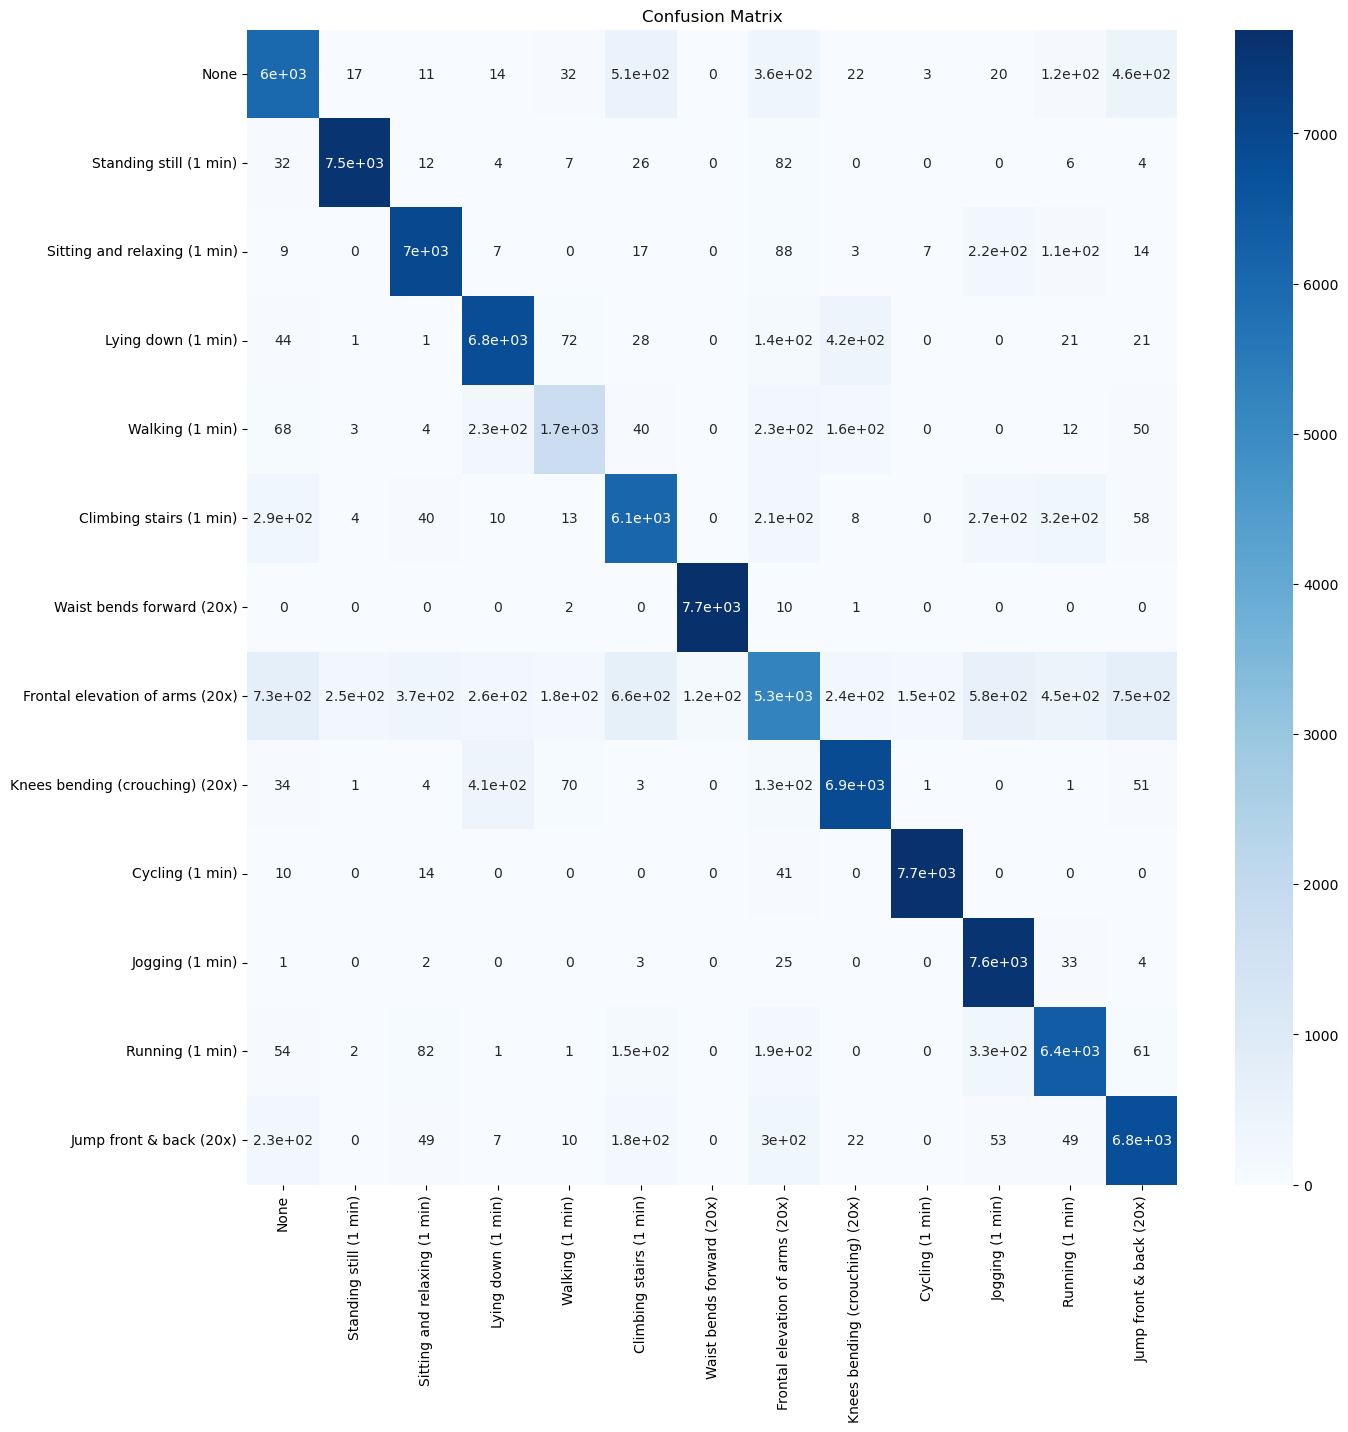

Accuracy Score: 87.0886%
Precision Score: 86.7291%
Recall Score: 86.9095%
F1 Score: 86.5609%


In [55]:
modeltest(t1,t2)